<a href="https://colab.research.google.com/github/Joacco11/TelecomX_parte2_Latam/blob/main/TelecomX_parte2_Latam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Telecom X – Parte 2: Predicción de Cancelación (Churn)

##🛠️ Preparación de los Datos

###Extracción del Archivo Tratado

In [380]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import RandomOverSampler
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import permutation_importance
url = 'https://raw.githubusercontent.com/Joacco11/TelecomX_Latam-Part-1/refs/heads/main/telecomx_clean.csv'
df = pd.read_csv(url, index_col="id_cliente")
df.head()

,churn,genero,adulto_mayor,pareja,dependientes,antiguedad_meses,servicio_telefonico,lineas_multiples,servicio_internet,seguridad_en_linea,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,facturacion_electronica,metodo_pago,cargo_mensual,cargo_total,Cuentas_Diarias
id_cliente,,,,,,,,,,,,,,,,,,,,,
0002-ORFBO,No,Female,False,True,True,9,True,No,DSL,No,...,No,Yes,Yes,No,One year,True,Mailed check,65.6,593.30,2.19
0003-MKNFE,No,Male,False,False,False,9,True,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,False,Mailed check,59.9,542.40,2.00
0004-TLHLJ,Yes,Male,False,False,False,4,True,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,True,Electronic check,73.9,280.85,2.46
0011-IGKFF,Yes,Male,True,True,False,13,True,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,True,Electronic check,98.0,1237.85,3.27
0013-EXCHZ,Yes,Female,True,True,False,3,True,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,True,Mailed check,83.9,267.40,2.80


>En el proyecto anterior no eliminé los valores nulos en **churn** y **cargo_total** porque lo que buscaba era representar la realidad del negocio, pero en el caso del desarrollo del modelo predictivo, realizaré la limpieza de estos campos ya que no los necesito

In [381]:
# 1. Eliminar filas con "No se sabe" en churn
df = df[df['churn'] != "No se sabe"]

# 2. Imputar valores nulos en cargo_total con la media
df['cargo_total'] = df['cargo_total'].fillna(df['cargo_total'].mean())

# 3. Verificar
print(df['churn'].value_counts())
print("Nulos en cargo_total:", df['cargo_total'].isna().sum())

churn
No     5174
Yes    1869
Name: count, dtype: int64
Nulos en cargo_total: 0



###Eliminación de Columnas Irrelevantes

>Id_cliente está como index. Cuentas_diarias no la  al ser una columna de caracter artificial.


In [382]:
df = df.drop(columns=['Cuentas_Diarias'])
df.shape

(7043, 20)

###Encoding

####Separación de target y variables

In [383]:
x = df.drop(columns=['churn'])
y = df['churn']

x.dtypes

,0
genero,object
adulto_mayor,bool
pareja,bool
dependientes,bool
antiguedad_meses,int64
servicio_telefonico,bool
lineas_multiples,object
servicio_internet,object
seguridad_en_linea,object
respaldo_en_linea,object


In [384]:
cat = x.select_dtypes(include=['object']).columns
num = x.select_dtypes(include=['int', 'float']).columns
bin = x.select_dtypes(include=['bool']).columns

print("Categóricas:", cat.tolist())
print("Numéricas:", num.tolist())
print("Booleanas:", bin.tolist())

Categóricas: ['genero', 'lineas_multiples', 'servicio_internet', 'seguridad_en_linea', 'respaldo_en_linea', 'proteccion_dispositivo', 'soporte_tecnico', 'streaming_tv', 'streaming_peliculas', 'tipo_contrato', 'metodo_pago']
Numéricas: ['antiguedad_meses', 'cargo_mensual', 'cargo_total']
Booleanas: ['adulto_mayor', 'pareja', 'dependientes', 'servicio_telefonico', 'facturacion_electronica']


####Tratamiento de categóricas


In [385]:
one_hot =  make_column_transformer((OneHotEncoder(drop='first'), cat), remainder='passthrough',
                                   sparse_threshold=0,force_int_remainder_cols=False)
x_enc = one_hot.fit_transform(x)
ohe_cols = one_hot.named_transformers_['onehotencoder'].get_feature_names_out(cat)
# Combinar nombres de OHE + resto de columnas
all_cols = list(ohe_cols) + [col for col in x.columns if col not in cat]

# Convertir a DataFrame
x = pd.DataFrame(x_enc, columns=all_cols, index=x.index)

print(x.shape)
print(all_cols)

(7043, 30)
['genero_Male', 'lineas_multiples_No phone service', 'lineas_multiples_Yes', 'servicio_internet_Fiber optic', 'servicio_internet_No', 'seguridad_en_linea_No internet service', 'seguridad_en_linea_Yes', 'respaldo_en_linea_No internet service', 'respaldo_en_linea_Yes', 'proteccion_dispositivo_No internet service', 'proteccion_dispositivo_Yes', 'soporte_tecnico_No internet service', 'soporte_tecnico_Yes', 'streaming_tv_No internet service', 'streaming_tv_Yes', 'streaming_peliculas_No internet service', 'streaming_peliculas_Yes', 'tipo_contrato_One year', 'tipo_contrato_Two year', 'metodo_pago_Credit card (automatic)', 'metodo_pago_Electronic check', 'metodo_pago_Mailed check', 'adulto_mayor', 'pareja', 'dependientes', 'antiguedad_meses', 'servicio_telefonico', 'facturacion_electronica', 'cargo_mensual', 'cargo_total']


####Tratamiento del target


In [386]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
y

array([0, 0, 1, ..., 0, 0, 0])

###Verificación de la Proporción de Cancelación (Churn)

In [387]:
# Conteo de cada clase
unique, counts = np.unique(y, return_counts=True)

# Proporción de cada clase
proporcion = counts / len(y)

for u, c, p in zip(unique, counts, proporcion):
    print(f"Clase {u}: {c} clientes ({p:.2%})")


Clase 0: 5174 clientes (73.46%)
Clase 1: 1869 clientes (26.54%)


###Balanceo de Clases

In [388]:
# Definir oversampler
oversampler = RandomOverSampler(random_state=42)

# Aplicar oversampling sobre X e y
X_res, y_res = oversampler.fit_resample(x, y)

print("Tamaño original:", len(y))
print("Tamaño balanceado:", len(y_res))

# Ver distribución después del oversampling
print(pd.Series(y_res).value_counts())


Tamaño original: 7043
Tamaño balanceado: 10348
0    5174
1    5174
Name: count, dtype: int64


In [389]:
x = X_res
y = y_res
df_train = pd.DataFrame.from_records(x, columns=all_cols)
df_train['churn'] = y
df_train.head()

/tmp/ipython-input-2020816562.py:3: FutureWarning: Passing a DataFrame to DataFrame.from_records is deprecated. Use set_index and/or drop to modify the DataFrame instead.
  df_train = pd.DataFrame.from_records(x, columns=all_cols)


,genero_Male,lineas_multiples_No phone service,lineas_multiples_Yes,servicio_internet_Fiber optic,servicio_internet_No,seguridad_en_linea_No internet service,seguridad_en_linea_Yes,respaldo_en_linea_No internet service,respaldo_en_linea_Yes,proteccion_dispositivo_No internet service,...,metodo_pago_Mailed check,adulto_mayor,pareja,dependientes,antiguedad_meses,servicio_telefonico,facturacion_electronica,cargo_mensual,cargo_total,churn
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,False,True,True,9,True,True,65.6,593.3,0
1,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,False,False,False,9,True,False,59.9,542.4,0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,False,False,False,4,True,True,73.9,280.85,1
3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,True,True,False,13,True,True,98.0,1237.85,1
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,True,True,False,3,True,True,83.9,267.4,1


##🎯 Correlación y Selección de Variables

####Análisis de Correlación

In [390]:
corr = df_train.corr()
corr['churn'].sort_values(ascending=False)

,churn
churn,1.000000
servicio_internet_Fiber optic,0.336075
metodo_pago_Electronic check,0.330166
cargo_mensual,0.220256
facturacion_electronica,0.219138
adulto_mayor,0.157474
streaming_tv_Yes,0.070800
streaming_peliculas_Yes,0.069518
lineas_multiples_Yes,0.036134
servicio_telefonico,0.006530


####Análisis Dirigido

>Me pareció lo más óptimo tener dos datas. df (Datos limpios sin aplicar el oversampling y one hot encoder) para realizar el análisis en esta sección. Y df_train (Con el oversampling y one hot encoder aplicado) para el uso del modelo XGBoost

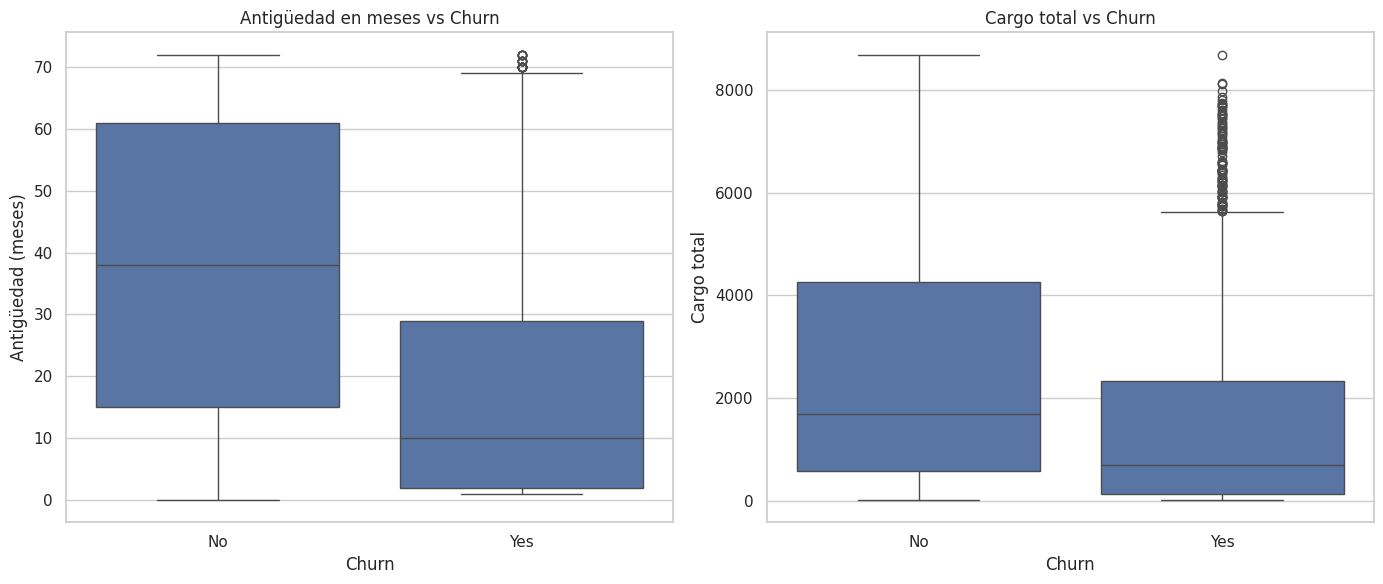

In [391]:
# Ajustar estilo
sns.set(style="whitegrid")

# Crear figura con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Boxplot 1: Antigüedad en meses vs churn ---
sns.boxplot(x='churn', y='antiguedad_meses', data=df, ax=axes[0])
axes[0].set_title("Antigüedad en meses vs Churn", fontsize=12)
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Antigüedad (meses)")

# --- Boxplot 2: Cargo total vs churn ---
sns.boxplot(x='churn', y='cargo_total', data=df, ax=axes[1])
axes[1].set_title("Cargo total vs Churn", fontsize=12)
axes[1].set_xlabel("Churn")
axes[1].set_ylabel("Cargo total")

plt.tight_layout()
plt.show()

>💡 Interpretación práctica para tu informe:

1. Tiempo de relación con la empresa es un factor más determinante que el gasto acumulado.

2. Gasto total también aporta información, pero es menos decisivo.

3. Ambos gráficos complementan el análisis de correlación: muestran la magnitud real de las diferencias entre grupos.
4. A demás se visualizan muchos valores atípicos en la columna [gasto_total]. Pero para el modelo XGBoost no afecta mucho

##🤖 Modelado Predictivo

####Separación de Datos(Train-Test)


In [392]:
X_train, X_test, y_train, y_test = train_test_split(x, y,stratify=y, test_size=0.3, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((7243, 30), (3105, 30), (7243,), (3105,))

####Modelo BaseLine

In [393]:
dummy = DummyClassifier()
dummy.fit(X_train, y_train)
dummy.score(X_test, y_test)

0.4998389694041868


####Random Forest

In [394]:
#Modifico la profundidad del arbol solo para que sea más legible. La Max taza de acierto es el anterior
modelo_arbol = DecisionTreeClassifier(max_depth=5)
modelo_arbol.fit(X_train, y_train)
modelo_arbol.score(X_test, y_test)

0.7600644122383253

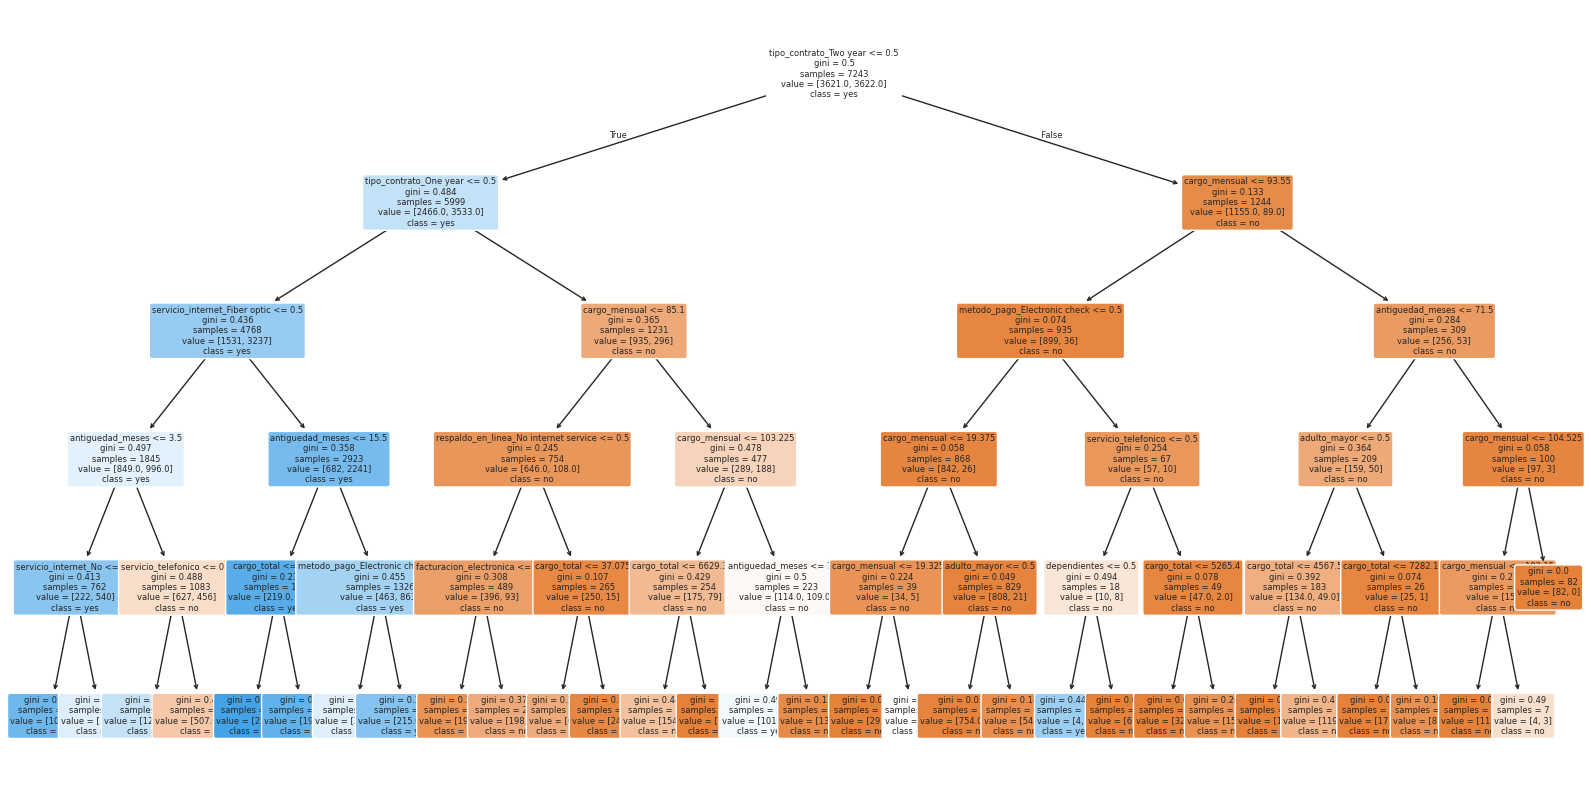

In [395]:
columnas = X_train.columns.to_list()
plt.figure(figsize=(20,10))  # 80,25 es muy grande para visualizar
plot_tree(modelo_arbol,
          feature_names=columnas,
          filled=True,
          class_names=['no','yes'],
          rounded=True,
          fontsize=6)
plt.show()

In [396]:
#modelo con más Precisión
modelo_arbol = DecisionTreeClassifier()
modelo_arbol.fit(X_train, y_train)
modelo_arbol.score(X_test, y_test)

0.8534621578099839

####KNN

#####Normalización

In [397]:
normalizacion = MinMaxScaler()
X_train_norm = normalizacion.fit_transform(X_train)

#####Entrenamiento

In [398]:
knn = KNeighborsClassifier()
knn.fit(X_train_norm, y_train)
x_test_norm = normalizacion.transform(X_test)
knn.score(x_test_norm, y_test)

0.7594202898550725

####Evaluación

In [399]:
lista = [('dummy', dummy, X_test),('RandomForest', modelo_arbol, X_test),('knn', knn, x_test_norm)]
for i in lista:
  print(f'La exactitud del modelo {i[0]}: {i[1].score(i[2], y_test)}')

La exactitud del modelo dummy: 0.4998389694041868
La exactitud del modelo RandomForest: 0.8534621578099839
La exactitud del modelo knn: 0.7594202898550725


##📋 Interpretación y Conclusiones

####Análisis de la Importancia de las Variables


#####RandomForest

                                      Variable  Importancia
28                               cargo_mensual     0.195570
29                                 cargo_total     0.172538
18                      tipo_contrato_Two year     0.152978
25                            antiguedad_meses     0.106252
17                      tipo_contrato_One year     0.104319
3                servicio_internet_Fiber optic     0.032281
23                                      pareja     0.022712
0                                  genero_Male     0.022494
10                  proteccion_dispositivo_Yes     0.019418
27                     facturacion_electronica     0.017927
20                metodo_pago_Electronic check     0.017926
6                       seguridad_en_linea_Yes     0.017337
8                        respaldo_en_linea_Yes     0.014837
22                                adulto_mayor     0.014457
24                                dependientes     0.013954
12                         soporte_tecni

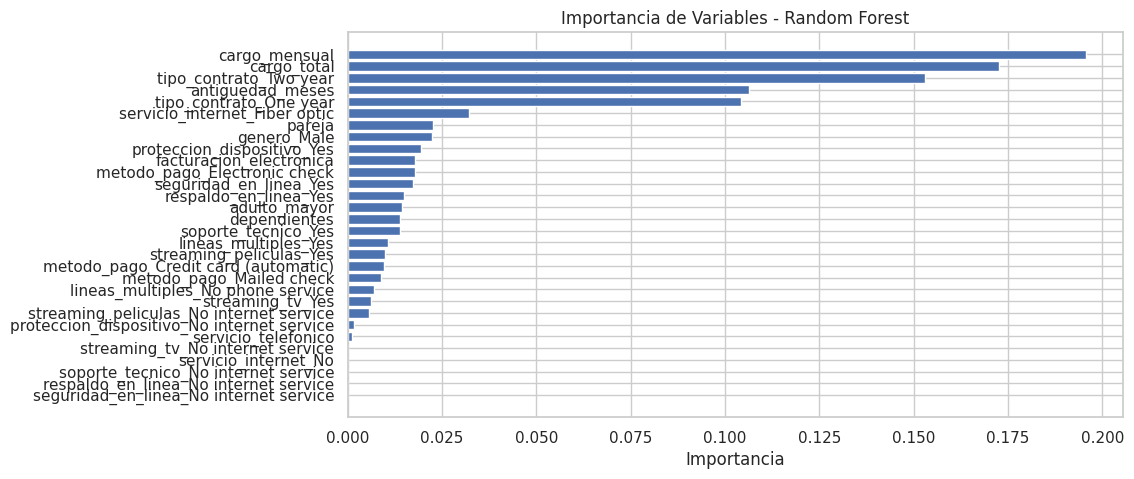

In [400]:
# Extraer importancia de variables
importancia = modelo_arbol.feature_importances_
columnas = X_train.columns
df_importancia = pd.DataFrame({'Variable': columnas, 'Importancia': importancia})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False)

# Mostrar top variables
print(df_importancia)

# Gráfico de barras
plt.figure(figsize=(10,5))
plt.barh(df_importancia['Variable'], df_importancia['Importancia'])
plt.gca().invert_yaxis()
plt.xlabel("Importancia")
plt.title("Importancia de Variables - Random Forest")
plt.show()


#####KNN

                                      Variable  Importancia
18                      tipo_contrato_Two year     0.018261
25                            antiguedad_meses     0.017424
29                                 cargo_total     0.009469
17                      tipo_contrato_One year     0.009018
22                                adulto_mayor     0.004605
3                servicio_internet_Fiber optic     0.004509
12                         soporte_tecnico_Yes     0.003478
6                       seguridad_en_linea_Yes     0.002544
10                  proteccion_dispositivo_Yes     0.002126
16                     streaming_peliculas_Yes     0.001771
21                    metodo_pago_Mailed check     0.000934
11         soporte_tecnico_No internet service     0.000000
5       seguridad_en_linea_No internet service     0.000000
4                         servicio_internet_No     0.000000
7        respaldo_en_linea_No internet service     0.000000
13            streaming_tv_No internet s

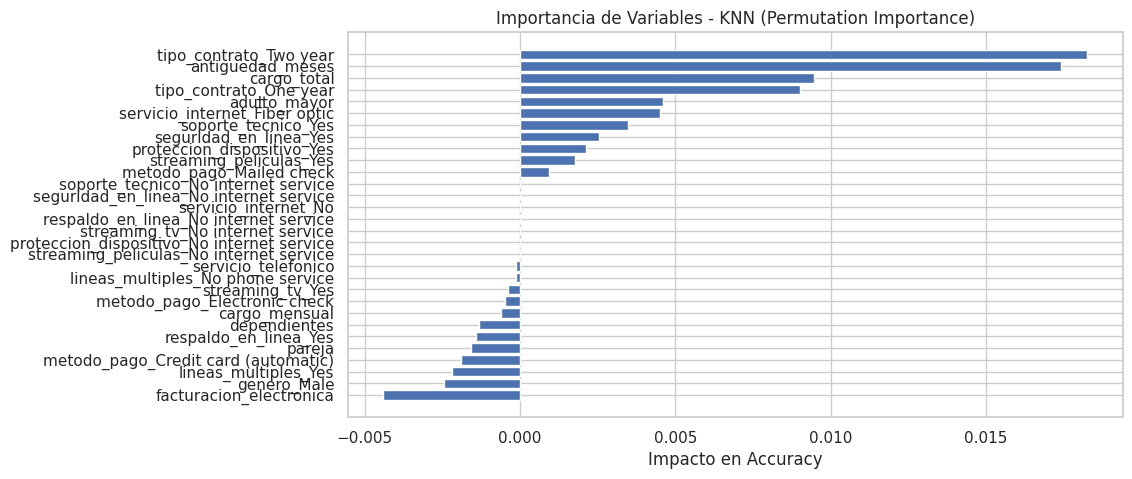

In [402]:
perm_importance = permutation_importance(knn, x_test_norm, y_test, n_repeats=10, random_state=42)
df_perm = pd.DataFrame({'Variable': X_train.columns, 'Importancia': perm_importance.importances_mean})
df_perm = df_perm.sort_values(by='Importancia', ascending=False)

print(df_perm)

# Gráfico
plt.figure(figsize=(10,5))
plt.barh(df_perm['Variable'], df_perm['Importancia'])
plt.gca().invert_yaxis()
plt.xlabel("Impacto en Accuracy")
plt.title("Importancia de Variables - KNN (Permutation Importance)")
plt.show()


####Conclusión

# Informe de Predicción de Cancelación – Telecom X

## 1. Contexto

Se realizó un análisis predictivo para identificar clientes con mayor probabilidad de cancelar sus servicios en Telecom X. El flujo de trabajo incluyó:

1. Limpieza y preparación de datos.
2. Codificación de variables categóricas (One-Hot Encoding).
3. Balanceo de clases mediante **oversampling**.
4. Análisis de correlación para variables numéricas y categorizadas.
5. División de la data y entrenamiento de modelos de clasificación: **Random Forest (RF), K-Nearest Neighbors (KNN)** y un modelo de referencia **Dummy**.
6. Evaluación del rendimiento y análisis de la importancia de las variables.

---

## 2. Variables más relevantes

### Análisis de correlación

| Variable                        | Correlación con churn |
| ------------------------------- | --------------------- |
| antiguedad\_meses               | -0.414                |
| tipo\_contrato\_Two year        | -0.391                |
| servicio\_internet\_Fiber optic | 0.336                 |
| metodo\_pago\_Electronic check  | 0.330                 |
| cargo\_total                    | -0.241                |
| cargo\_mensual                  | 0.220                 |

**CONCLUSIÓN**: Las variables con mayor correlación absoluta son las que influyen más directamente en la cancelación, tanto positiva como negativamente.

### Importancia de variables según los modelos

#### Random Forest

| Variable                 | Importancia |
| ------------------------ | ----------- |
| cargo\_mensual           | 0.196       |
| cargo\_total             | 0.173       |
| tipo\_contrato\_Two year | 0.153       |
| antiguedad\_meses        | 0.106       |
| tipo\_contrato\_One year | 0.104       |

#### KNN

| Variable                 | Importancia |
| ------------------------ | ----------- |
| tipo\_contrato\_Two year | 0.018       |
| antiguedad\_meses        | 0.017       |
| cargo\_total             | 0.009       |
| tipo\_contrato\_One year | 0.009       |

**CONCLUSIÓN**: Coincidiendo parcialmente con la correlación, **el tipo de contrato, antigüedad, gasto mensual y total** son los factores clave en la predicción de churn.

---

## 3. Rendimiento de los modelos

| Modelo           | Accuracy |
| ---------------- | -------- |
| Dummy (baseline) | 0.50     |
| Random Forest    | 0.856    |
| KNN              | 0.759    |

**OBSERVACIÓN**: Random Forest obtiene el mejor desempeño, lo que indica que captura relaciones no lineales e interacciones entre variables mejor que KNN.

---

## 4. Insights y estrategias de retención

1. **Antigüedad y tipo de contrato**

   * Clientes con contratos de dos años y mayor antigüedad muestran menor probabilidad de cancelación.
   * Estrategia: Incentivar la renovación de contratos y ofrecer beneficios para clientes de larga permanencia.

2. **Gasto mensual y total**

   * Clientes con cargos más altos tienen mayor riesgo de cancelar.
   * Estrategia: Proponer planes más ajustados al consumo o promociones que aumenten la percepción de valor.

3. **Método de pago y servicio de Internet**

   * Pago electrónico y fibra óptica se asocian a mayor churn.
   * Estrategia: Implementar recordatorios de pago, soporte personalizado y mejoras en la experiencia de Internet.

---

## 5. Conclusión

El análisis confirma que **antigüedad, tipo de contrato, cargos y servicios contratados** son los factores más relevantes para predecir la cancelación de clientes en Telecom X.
Implementar estrategias personalizadas de retención, basadas en estos insights, permitirá reducir significativamente el churn y mejorar la satisfacción de los clientes.
